# Inference Guide for SynthRCT

This notebook is an end-to-end walkthrough for running inference with SynthRCT.

1. Sample latent deformation codes given a moving CT volume.
2. Decode them into full-volume deformation fields. 
3. Visualize random deformations.
4. Summarize the patient-specific latent space using PCA and 2D visualizations. 
5. Export interpolation assets.  

The notebook operates on real data and uses the inference helpers in `rctsynth.tools`. Model geometry and encoder padding are recovered from the checkpoint automatically.

---

## Environment


In [ ]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve()
if (REPO_ROOT / "src").exists():
    sys.path.insert(0, str(REPO_ROOT / "src"))
    
import numpy as np
from IPython.display import Image
import matplotlib.pyplot as plt
from types import SimpleNamespace
import nibabel as nib

from rctsynth.utils.animation import (
    create_slicer_lung_gif,
    save_volume_gif,
)
from rctsynth.utils.inference import (
    decode_latent,
    run_random_samples,
)
from rctsynth.utils.io import (
    load_nifti_dhw,
    save_flow_nifti,
    save_nifti_dhw,
)
from rctsynth.utils.latent import (
    encode_identity_z,
    pca_scores_for_latents,
    pc_traversal_latents,
    sample_prior_z,
)
from rctsynth.utils.core import model_device
from rctsynth.utils.model_loading import load_vae

## Configure paths

Set the paths to the released checkpoint, the preprocessed moving CT, and the corresponding lung mask. The CT loader applies min–max normalization when requested, so disable it if the volume is already normalized exactly as expected by the model.

The optional 3D lung visualization requires a local installation of [3D Slicer](https://www.slicer.org/). Set `SLICER_EXECUTABLE` to the path of your Slicer executable. This dependency is only needed for generating the rendered 3D GIF; the remaining inference and 2D visualization steps can run without it.


In [ ]:
CKPT_PATH = Path("checkpoints/rctsynth.ckpt")
MOVING_NIFTI_PATH = Path("data/demo/preprocessed_ct.nii.gz")
MASK_NIFTI_PATH = Path("data/demo/lung_mask.nii.gz")
OUTPUT_DIR = Path("demo_outputs")
GIF_DIR = OUTPUT_DIR / "gifs"
GIF_DIR.mkdir(parents=True, exist_ok=True)
SLICER_EXECUTABLE = Path(
    "/path/to/Slicer"
)

DEVICE = "cuda"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
moving_dhw, nifti_affine = load_nifti_dhw(MOVING_NIFTI_PATH, normalize=True)
mask, _ = load_nifti_dhw(MASK_NIFTI_PATH)

module, model = load_vae(
    CKPT_PATH,
    device=DEVICE,
)

## One random deformation

A single latent code is sampled, decoded to a full-volume SVF/DVF, and applied to the moving CT. The figure shows an axial slice of the original and warped image, the DVF magnitude inside the anatomy mask, and an in-plane vector view of the deformation.

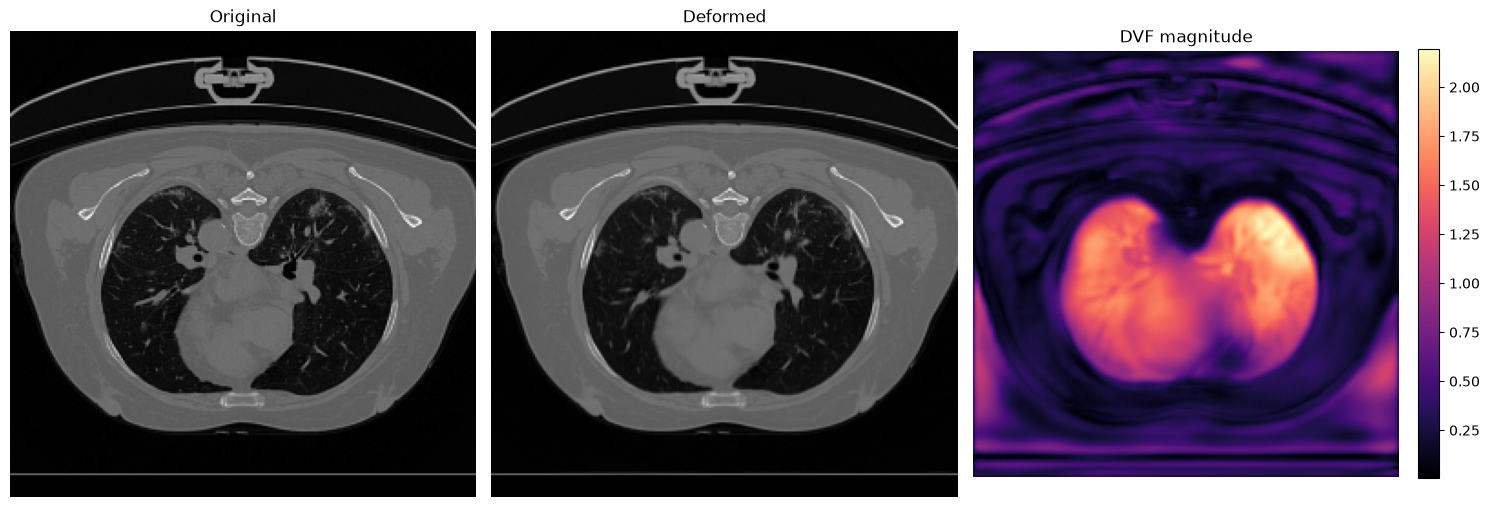

In [5]:
# Sample one random deformation.
z = sample_prior_z(
    model=model,
    moving_full_dhw=moving_dhw,
    n_samples=1,
)[0]

# Decode the latent, integrate the SVF, and warp the full volume.
sample = decode_latent(
    model=model,
    moving_dhw=moving_dhw,
    z=z,
)

# Plot the middle axial slice.
slice_index = moving_dhw.shape[0] // 2
flow_magnitude = np.linalg.norm(sample.flow_3dhw, axis=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(moving_dhw[slice_index], cmap="gray")
axes[0].set_title("Original")

axes[1].imshow(sample.warped_dhw[slice_index], cmap="gray")
axes[1].set_title("Deformed")

field_image = axes[2].imshow(
    flow_magnitude[slice_index],
    cmap="magma",
)
axes[2].set_title("DVF magnitude")

fig.colorbar(
    field_image,
    ax=axes[2],
    fraction=0.046,
    pad=0.04,
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [6]:
# Save the complete warped volume.
output_path = OUTPUT_DIR / "random_deformed_ct.nii.gz"
output_path.parent.mkdir(parents=True, exist_ok=True)

save_nifti_dhw(
    sample.warped_dhw,
    output_path,
    nifti_affine,
)

print(f"Saved to: {output_path}")

Saved to: demo_outputs\random_deformed_ct.nii.gz


## Interpolate along the principal component

This traversal is anchored at the model’s encoded identity pair `(moving, moving)` and moves along PC1 in both directions. It saves each intermediate warped volume and DVF as NIfTI and displays the corresponding middle axial slices.

> **Warning**
>
> Full-volume decoding and warping can be computationally expensive. To reduce runtime, increase the `batch_size` passed to `decode_latent()` if your available GPU memory allows it, or decrease the number of interpolation steps.


In [7]:
N_SAMPLES = 30

latents = sample_prior_z(
    model=model,
    moving_full_dhw=moving_dhw,
    n_samples=N_SAMPLES,
    seed=13,
).cpu().numpy()

pca = pca_scores_for_latents(latents)

In [8]:
z_identity = (
    encode_identity_z(
        model=model,
        moving_full_dhw=moving_dhw,
    )[0]
    .cpu()
    .numpy()
)

traversal_latents = pc_traversal_latents(
    pca,
    pc_index=0,
    num_steps=9,
    n_std=2.0,
    base_z=z_identity,
)

alphas = np.linspace(
    -2.0,
    2.0,
    len(traversal_latents),
)

traversal_samples = [
    decode_latent(
        model=model,
        moving_dhw=moving_dhw,
        z=z,
        batch_size=1,
    )
    for z in traversal_latents
]

traversal_dir = OUTPUT_DIR / "pc1_traversal"
traversal_dir.mkdir(parents=True, exist_ok=True)

for index, (alpha, sample) in enumerate(
    zip(alphas, traversal_samples)
):
    prefix = f"step_{index:02d}_std_{alpha:+.1f}"

    save_nifti_dhw(
        sample.warped_dhw,
        traversal_dir / f"{prefix}_warped.nii.gz",
        nifti_affine,
    )

    save_flow_nifti(
        sample.flow_3dhw,
        traversal_dir / f"{prefix}_dvf.nii.gz",
        nifti_affine,
    )

print(f"Saved traversal to: {traversal_dir}")

Saved traversal to: demo_outputs\pc1_traversal


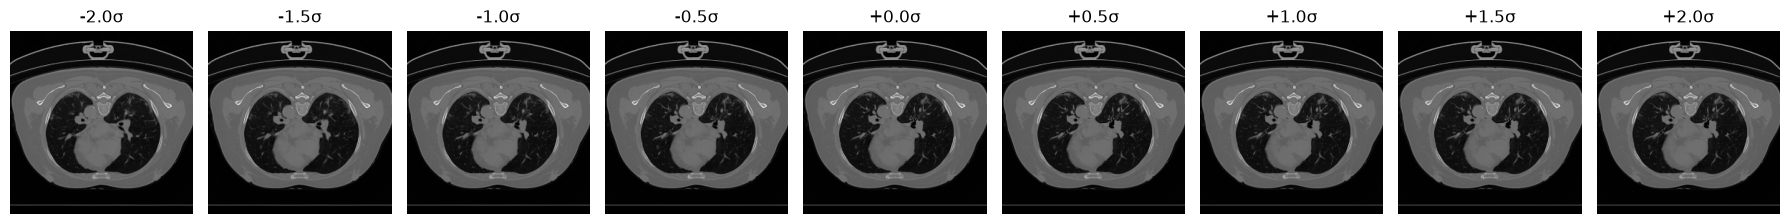

In [16]:
slice_index = moving_dhw.shape[0] // 2

fig, axes = plt.subplots(1, len(traversal_samples), figsize=(18, 3))
for ax, alpha, sample in zip(axes, alphas, traversal_samples):
    ax.imshow(sample.warped_dhw[slice_index], cmap="gray")
    ax.set_title(f"{alpha:+.1f}σ")
    ax.axis("off")
plt.tight_layout()
plt.show()

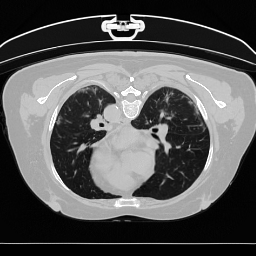

In [11]:
slice_index = moving_dhw.shape[0] // 2

gif_2d_path = save_volume_gif(
    [sample.warped_dhw for sample in traversal_samples],
    GIF_DIR / "pc1_interpolation_axial.gif",
    plane="axial",
    slice_index=slice_index,
    fps=7,
)

gif_path = Path(gif_2d_path)
display(Image(data=gif_path.read_bytes(), format="gif"))

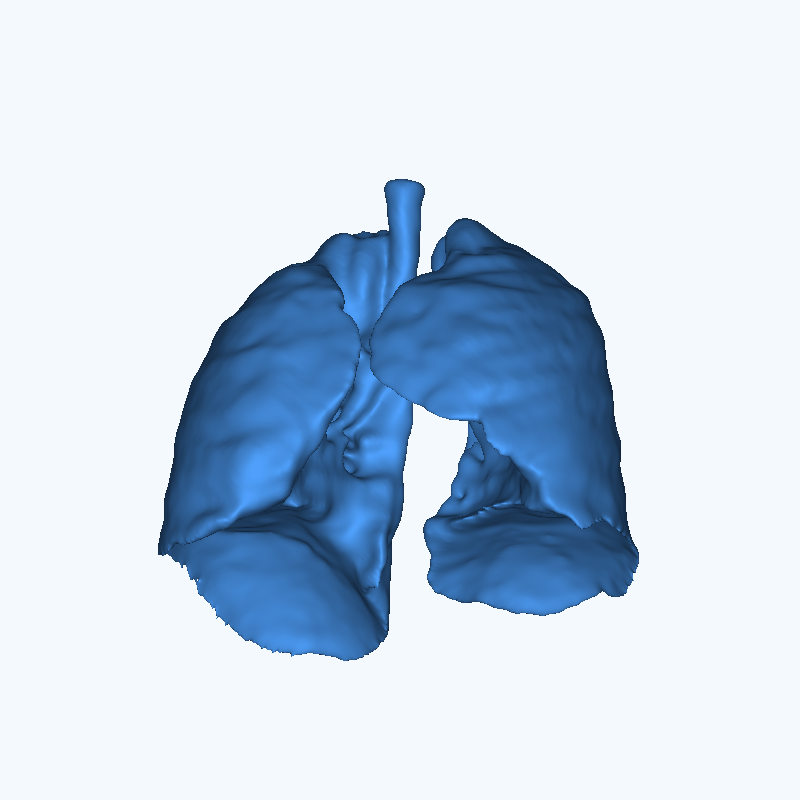

In [8]:
gif_3d_path = create_slicer_lung_gif(
    mask_dhw=mask,
    samples=traversal_samples,
    output_dir=GIF_DIR / "pc1_lung_3d",
    affine=nifti_affine,
    device=model_device(model),
    slicer_executable=SLICER_EXECUTABLE,
    gif_name="pc1_lung_3d.gif",
    fps=6,
)

gif_path = Path(gif_3d_path)
display(Image(data=gif_path.read_bytes(), format="gif"))